In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv('birth_weight.csv', encoding='latin-1')

In [3]:
data

,age,pre_pregnancy_bmi,gestational_age_weeks,blood_pressure_systolic,blood_pressure_diastolic,hemoglobin_level,number_of_prenatal_visits,has_diabetes,has_hypertension,education_level,iron_supplementation,birth_weight_category
0,38,23.60,38,108,66,10.81,1,NO,NO,Primary,0,Normal
1,29,21.89,35,147,95,12.02,10,YES,NO,Primary,1,Normal
2,35,28.90,40,113,70,10.41,1,NO,YES,Primary,1,Low
3,27,32.00,36,104,87,11.77,2,NO,NO,Higher,1,Normal
4,23,16.89,35,107,76,10.70,11,NO,NO,NaN,1,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...
555,40,24.53,39,150,92,12.60,4,YES,YES,Secondary,1,Normal
556,38,23.07,38,135,78,10.08,3,NO,YES,Higher,0,Low
557,29,26.22,37,149,61,10.01,3,NO,NO,Secondary,0,Low
558,18,29.37,37,146,80,10.21,2,YES,NO,Higher,1,Low


<Axes: >

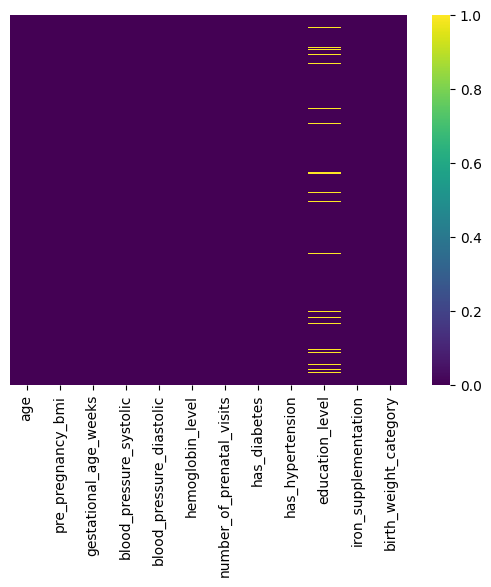

In [4]:
sns.heatmap(data.isnull(),yticklabels=False, cmap="viridis")

In [5]:
data = data.drop(columns=['education_level','number_of_prenatal_visits'])

<Axes: >

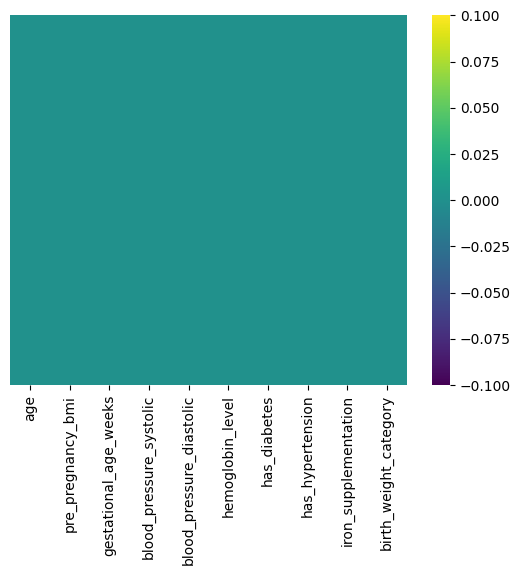

In [6]:
sns.heatmap(data.isnull(),yticklabels=False, cmap="viridis")

In [7]:
data

,age,pre_pregnancy_bmi,gestational_age_weeks,blood_pressure_systolic,blood_pressure_diastolic,hemoglobin_level,has_diabetes,has_hypertension,iron_supplementation,birth_weight_category
0,38,23.60,38,108,66,10.81,NO,NO,0,Normal
1,29,21.89,35,147,95,12.02,YES,NO,1,Normal
2,35,28.90,40,113,70,10.41,NO,YES,1,Low
3,27,32.00,36,104,87,11.77,NO,NO,1,Normal
4,23,16.89,35,107,76,10.70,NO,NO,1,Normal
...,...,...,...,...,...,...,...,...,...,...
555,40,24.53,39,150,92,12.60,YES,YES,1,Normal
556,38,23.07,38,135,78,10.08,NO,YES,0,Low
557,29,26.22,37,149,61,10.01,NO,NO,0,Low
558,18,29.37,37,146,80,10.21,YES,NO,1,Low


In [8]:
data['has_diabetes'].value_counts()

has_diabetes
NO     467
YES     93
Name: count, dtype: int64

In [9]:
data['has_diabetes'] = data['has_diabetes'].str.replace('NO', '0', regex=False)
data['has_diabetes'] = data['has_diabetes'].str.replace('YES', '1', regex=False)

In [10]:
data['has_hypertension'].value_counts()

has_hypertension
NO     444
YES    116
Name: count, dtype: int64

In [11]:
data['has_hypertension'] = data['has_hypertension'].str.replace('NO', '0', regex=False)
data['has_hypertension'] = data['has_hypertension'].str.replace('YES', '1', regex=False)

In [12]:
data

,age,pre_pregnancy_bmi,gestational_age_weeks,blood_pressure_systolic,blood_pressure_diastolic,hemoglobin_level,has_diabetes,has_hypertension,iron_supplementation,birth_weight_category
0,38,23.60,38,108,66,10.81,0,0,0,Normal
1,29,21.89,35,147,95,12.02,1,0,1,Normal
2,35,28.90,40,113,70,10.41,0,1,1,Low
3,27,32.00,36,104,87,11.77,0,0,1,Normal
4,23,16.89,35,107,76,10.70,0,0,1,Normal
...,...,...,...,...,...,...,...,...,...,...
555,40,24.53,39,150,92,12.60,1,1,1,Normal
556,38,23.07,38,135,78,10.08,0,1,0,Low
557,29,26.22,37,149,61,10.01,0,0,0,Low
558,18,29.37,37,146,80,10.21,1,0,1,Low


In [13]:
X = data.drop('birth_weight_category', axis=1)
y = data['birth_weight_category']

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=36)

In [15]:
def model_acc(model):
    model.fit(X_train, y_train)
    acc = model.score(X_test, y_test)
    print(str(model)+ ' --> ' +str(acc))

In [16]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=3)
model_acc(knn)

from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression()
model_acc(logreg)

KNeighborsClassifier(n_neighbors=3) --> 0.9226190476190477
LogisticRegression() --> 0.8630952380952381


C:\Users\Kale\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [17]:
predict=knn.predict(X_test)

<class 'numpy.ndarray'>
<class 'pandas.core.series.Series'>


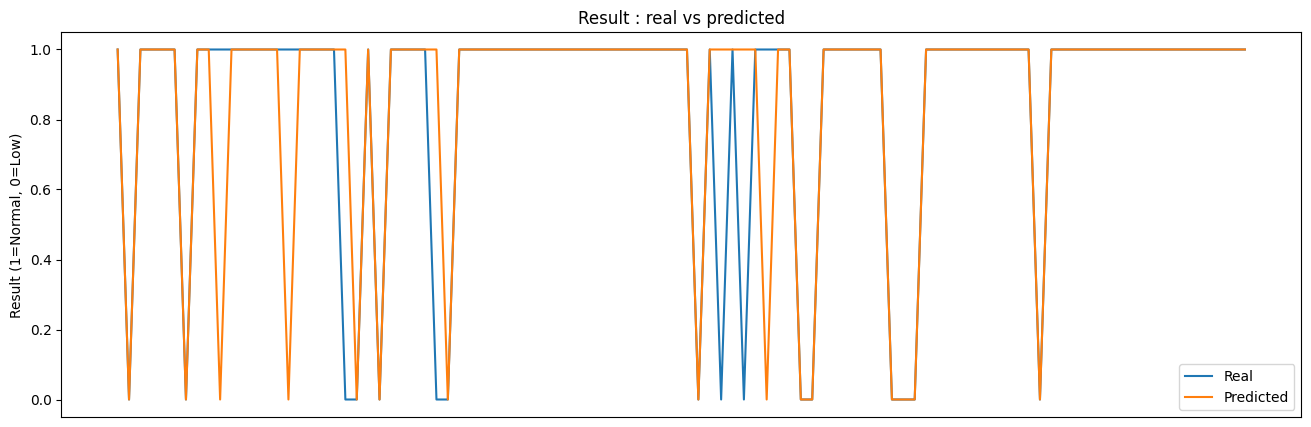

In [18]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
le.fit(["Low","Normal"])

A = le.transform(y_test).reshape(-1, 1)
B = le.transform(predict).reshape(-1, 1)

print(type(predict))
print(type(y_test))

plt.rcParams['figure.figsize'] = 16, 5
plt.figure()
plt.plot(A[-100:], label="Real")
plt.plot(B[-100:], label="Predicted")
plt.legend()
plt.title("Result : real vs predicted")
plt.ylabel("Result (1=Normal, 0=Low)")
plt.xticks(())
plt.show()

In [19]:
import pickle
# save model to file
pickle.dump(knn, open("birth_weight_model.dat", "wb"))

In [20]:
with open('birth_weight_model.dat' , 'rb') as f:
    model = pickle.load(f)

In [21]:
X

,age,pre_pregnancy_bmi,gestational_age_weeks,blood_pressure_systolic,blood_pressure_diastolic,hemoglobin_level,has_diabetes,has_hypertension,iron_supplementation
0,38,23.60,38,108,66,10.81,0,0,0
1,29,21.89,35,147,95,12.02,1,0,1
2,35,28.90,40,113,70,10.41,0,1,1
3,27,32.00,36,104,87,11.77,0,0,1
4,23,16.89,35,107,76,10.70,0,0,1
...,...,...,...,...,...,...,...,...,...
555,40,24.53,39,150,92,12.60,1,1,1
556,38,23.07,38,135,78,10.08,0,1,0
557,29,26.22,37,149,61,10.01,0,0,0
558,18,29.37,37,146,80,10.21,1,0,1


In [22]:
y

0      Normal
1      Normal
2         Low
3      Normal
4      Normal
        ...  
555    Normal
556       Low
557       Low
558       Low
559    Normal
Name: birth_weight_category, Length: 560, dtype: object

In [24]:
model.predict([[38,23.60,38,108,66,10.81,1,0,0]])[0]

C:\Users\Kale\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


'Normal'

In [ ]:
from sklearn.metrics import classification_report

print("Classification Report:")
print(classification_report(y_test, predict))